In [1]:
!pip install yfinance pandas requests fredapi -q

In [9]:
!pip install yfinance pandas requests fredapi matplotlib reportlab -q

In [11]:
import pandas as pd
import numpy as np
import yfinance as yf
import requests
import warnings
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

# Período de análise
FIM   = datetime.today()
INICIO = FIM - timedelta(days=180)

# Pesos dos indicadores por setor
PESOS_ITALIA = {
    "btp_bund_spread": 0.30,
    "pmi_industrial":  0.25,
    "eur_brl":         0.25,
    "capital_flow":    0.20,
}

PESOS_ENERGIA = {
    "di_futuro":  0.35,
    "enbl3":      0.25,
    "egie3":      0.25,
    "eur_brl":    0.15,
}

PESOS_AGRO = {
    "inadimplencia": 0.35,
    "soja":          0.25,
    "acucar":        0.20,
    "agro3":         0.20,
}

print("✓ Configurações carregadas")
print(f"  Período: {INICIO.strftime('%d/%m/%Y')} → {FIM.strftime('%d/%m/%Y')}")

✓ Configurações carregadas
  Período: 10/11/2025 → 09/05/2026


In [19]:
print("=" * 50)
print("MÓDULO 1 — COLETA DEFINITIVA")
print("=" * 50)

SUA_CHAVE_FRED = "849985870ad3370e7d9341d47f6eb0de"

# ── Funções de coleta ─────────────────────────────────────────────────────────

def coletar_fred(series_id, nome):
    try:
        url = "https://api.stlouisfed.org/fred/series/observations"
        params = {
            "series_id": series_id,
            "api_key": SUA_CHAVE_FRED,
            "file_type": "json",
            "observation_start": INICIO.strftime("%Y-%m-%d"),
            "observation_end": FIM.strftime("%Y-%m-%d"),
        }
        r = requests.get(url, params=params, timeout=10)
        obs = r.json().get("observations", [])
        s = pd.Series(
            {o["date"]: float(o["value"]) for o in obs if o["value"] != "."},
            name=nome,
        )
        s.index = pd.to_datetime(s.index)
        if s.empty:
            print(f"  ✗ {nome} — série vazia")
        else:
            print(f"  ✓ {nome} ({len(s)} pontos)")
        return s
    except Exception as e:
        print(f"  ✗ {nome} — {e}")
        return pd.Series(name=nome, dtype=float)

def coletar_yfinance(ticker, nome):
    try:
        df = yf.download(ticker, start=INICIO, end=FIM,
                         progress=False, auto_adjust=True)
        s = df["Close"].squeeze()
        s.name = nome
        s.index = pd.to_datetime(s.index).tz_localize(None)
        if s.empty:
            print(f"  ✗ {nome} — série vazia")
        else:
            print(f"  ✓ {nome} ({len(s)} pontos)")
        return s
    except Exception as e:
        print(f"  ✗ {nome} — {e}")
        return pd.Series(name=nome, dtype=float)

def coletar_bcb(codigo, nome):
    try:
        url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados"
        params = {
            "formato": "json",
            "dataInicial": INICIO.strftime("%d/%m/%Y"),
            "dataFinal":   FIM.strftime("%d/%m/%Y"),
        }
        r = requests.get(url, params=params, timeout=10)
        dados = r.json()
        s = pd.Series(
            {d["data"]: float(d["valor"]) for d in dados},
            name=nome,
        )
        s.index = pd.to_datetime(s.index, dayfirst=True)
        if s.empty:
            print(f"  ✗ {nome} — série vazia")
        else:
            print(f"  ✓ {nome} ({len(s)} pontos)")
        return s
    except Exception as e:
        print(f"  ✗ {nome} — {e}")
        return pd.Series(name=nome, dtype=float)

def expandir_para_diario(serie, idx_diario):
    """Expande série mensal/semanal para frequência diária via forward fill."""
    return serie.reindex(idx_diario).ffill().bfill()

# ── Indicadores italianos ─────────────────────────────────────────────────────
print("\n🇮🇹 Indicadores italianos:")

btp_10y  = coletar_fred("IRLTLT01ITM156N", "btp_10y")
bund_10y = coletar_fred("IRLTLT01DEM156N", "bund_10y")

if not btp_10y.empty and not bund_10y.empty:
    idx = btp_10y.index.intersection(bund_10y.index)
    btp_bund = (btp_10y.loc[idx] - bund_10y.loc[idx]).rename("btp_bund_spread")
    print(f"  ✓ btp_bund_spread calculado ({len(btp_bund)} pontos)")
else:
    btp_bund = pd.Series(name="btp_bund_spread", dtype=float)
    print("  ✗ btp_bund_spread — falhou")

eur_brl      = coletar_yfinance("EURBRL=X",    "eur_brl")
capital_flow = coletar_fred("IRSTCI01ITM156N", "capital_flow")
ewi          = coletar_yfinance("EWI",          "ewi")       # ETF MSCI Italy
ftsemib      = coletar_yfinance("FTSEMIB.MI",   "ftsemib")   # Bolsa italiana

# ── Energia & Infraestrutura ──────────────────────────────────────────────────
print("\n⚡ Energia & Infraestrutura:")

selic  = coletar_bcb(11,           "selic")
cpfe3  = coletar_yfinance("CPFE3.SA",  "cpfe3")
taee11 = coletar_yfinance("TAEE11.SA", "taee11")

# ── Agronegócio ───────────────────────────────────────────────────────────────
print("\n🌾 Agronegócio:")

inadimplencia = coletar_bcb(21112,           "inadimplencia")
soja          = coletar_yfinance("ZS=F",     "soja")
acucar        = coletar_yfinance("SB=F",     "acucar")
agro3         = coletar_yfinance("AGRO3.SA", "agro3")
slce3         = coletar_yfinance("SLCE3.SA", "slce3")

print("\n✓ Coleta concluída!")

MÓDULO 1 — COLETA DEFINITIVA

🇮🇹 Indicadores italianos:
  ✓ btp_10y (4 pontos)
  ✓ bund_10y (5 pontos)
  ✓ btp_bund_spread calculado (4 pontos)
  ✓ eur_brl (128 pontos)
  ✓ capital_flow (5 pontos)
  ✓ ewi (124 pontos)
  ✓ ftsemib (122 pontos)

⚡ Energia & Infraestrutura:
  ✓ selic (122 pontos)
  ✓ cpfe3 (120 pontos)
  ✓ taee11 (120 pontos)

🌾 Agronegócio:
  ✓ inadimplencia (5 pontos)
  ✓ soja (124 pontos)
  ✓ acucar (124 pontos)
  ✓ agro3 (120 pontos)
  ✓ slce3 (120 pontos)

✓ Coleta concluída!


In [20]:
print("=" * 50)
print("MÓDULO 2 — PROCESSAMENTO")
print("=" * 50)

idx_diario = eur_brl.dropna().index

def processar_setor(indicadores: dict) -> tuple:
    series_alinhadas = {}
    for nome, serie in indicadores.items():
        if serie.dropna().empty:
            print(f"  ⚠ {nome} ignorado — sem dados")
            continue
        s = expandir_para_diario(serie, idx_diario)
        series_alinhadas[nome] = s

    df = pd.DataFrame(series_alinhadas).dropna(how="all")
    df = df.ffill().bfill()
    df_norm = (df - df.mean()) / df.std()
    df_norm = df_norm.clip(-3, 3)

    return df, df_norm

# Dicionários de indicadores atualizados
indicadores_italia = {
    "btp_bund_spread": btp_bund,
    "eur_brl":         eur_brl,
    "capital_flow":    capital_flow,
    "ewi":             ewi,
    "ftsemib":         ftsemib,
}

indicadores_energia = {
    "selic":   selic,
    "cpfe3":   cpfe3,
    "taee11":  taee11,
    "eur_brl": eur_brl,
}

indicadores_agro = {
    "inadimplencia": inadimplencia,
    "soja":          soja,
    "acucar":        acucar,
    "agro3":         agro3,
    "slce3":         slce3,
}

# Pesos atualizados
PESOS_ITALIA = {
    "btp_bund_spread": 0.35,
    "capital_flow":    0.20,
    "eur_brl":         0.20,
    "ewi":             0.15,
    "ftsemib":         0.10,
}

PESOS_ENERGIA = {
    "selic":   0.40,
    "cpfe3":   0.25,
    "taee11":  0.20,
    "eur_brl": 0.15,
}

PESOS_AGRO = {
    "inadimplencia": 0.30,
    "soja":          0.25,
    "acucar":        0.20,
    "agro3":         0.15,
    "slce3":         0.10,
}

# Processar
print("\nProcessando setores:")
df_italia_raw,  df_italia_norm  = processar_setor(indicadores_italia)
df_energia_raw, df_energia_norm = processar_setor(indicadores_energia)
df_agro_raw,    df_agro_norm    = processar_setor(indicadores_agro)

print(f"\n✓ Itália      — {df_italia_norm.shape}")
print(f"✓ Energia     — {df_energia_norm.shape}")
print(f"✓ Agronegócio — {df_agro_norm.shape}")

MÓDULO 2 — PROCESSAMENTO

Processando setores:

✓ Itália      — (128, 5)
✓ Energia     — (128, 4)
✓ Agronegócio — (128, 5)


In [7]:
print("=== DIAGNÓSTICO ===")

print("\n🇮🇹 Itália:")
for nome, serie in indicadores_italia.items():
    print(f"  {nome}: {len(serie)} pontos — vazia: {serie.dropna().empty}")

print("\n⚡ Energia:")
for nome, serie in indicadores_energia.items():
    print(f"  {nome}: {len(serie)} pontos — vazia: {serie.dropna().empty}")

print("\n🌾 Agro:")
for nome, serie in indicadores_agro.items():
    print(f"  {nome}: {len(serie)} pontos — vazia: {serie.dropna().empty}")

print("\n📊 DataFrames normalizados:")
print(f"  df_italia_norm:  {df_italia_norm.shape}")
print(f"  df_energia_norm: {df_energia_norm.shape}")
print(f"  df_agro_norm:    {df_agro_norm.shape}")

=== DIAGNÓSTICO ===

🇮🇹 Itália:
  btp_bund_spread: 0 pontos — vazia: True
  pmi_industrial: 0 pontos — vazia: True
  eur_brl: 128 pontos — vazia: False
  capital_flow: 0 pontos — vazia: True

⚡ Energia:
  di_futuro: 0 pontos — vazia: True
  enbl3: 0 pontos — vazia: True
  egie3: 120 pontos — vazia: False
  eur_brl: 128 pontos — vazia: False

🌾 Agro:
  inadimplencia: 5 pontos — vazia: False
  soja: 124 pontos — vazia: False
  acucar: 124 pontos — vazia: False
  agro3: 120 pontos — vazia: False

📊 DataFrames normalizados:
  df_italia_norm:  (128, 4)
  df_energia_norm: (128, 4)
  df_agro_norm:    (130, 4)


In [13]:
print("=== DIAGNÓSTICO ===")

print("\n🇮🇹 Itália:")
for nome, serie in indicadores_italia.items():
    print(f"  {nome}: {len(serie)} pontos — vazia: {serie.dropna().empty}")

print("\n⚡ Energia:")
for nome, serie in indicadores_energia.items():
    print(f"  {nome}: {len(serie)} pontos — vazia: {serie.dropna().empty}")

print("\n🌾 Agro:")
for nome, serie in indicadores_agro.items():
    print(f"  {nome}: {len(serie)} pontos — vazia: {serie.dropna().empty}")

=== DIAGNÓSTICO ===

🇮🇹 Itália:
  btp_bund_spread: 0 pontos — vazia: True
  pmi_industrial: 0 pontos — vazia: True
  eur_brl: 128 pontos — vazia: False
  capital_flow: 0 pontos — vazia: True

⚡ Energia:
  di_futuro: 0 pontos — vazia: True
  enbl3: 0 pontos — vazia: True
  egie3: 120 pontos — vazia: False
  eur_brl: 128 pontos — vazia: False

🌾 Agro:
  inadimplencia: 5 pontos — vazia: False
  soja: 124 pontos — vazia: False
  acucar: 124 pontos — vazia: False
  agro3: 120 pontos — vazia: False


In [14]:
# Testando tickers alternativos
print("Testando ativos do setor elétrico:")
for ticker in ["ENBL3.SA", "ENBR3.SA", "CPFE3.SA", "TAEE11.SA"]:
    df = yf.download(ticker, start=INICIO, end=FIM, progress=False, auto_adjust=True)
    status = f"{len(df)} pontos" if not df.empty else "VAZIO"
    print(f"  {ticker}: {status}")

print("\nTestando séries do BCB:")
for codigo, nome in [(4189, "Selic diária"), (12466, "DI futuro"), (21112, "Inadimplência agro")]:
    try:
        url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados"
        params = {"formato": "json",
                  "dataInicial": INICIO.strftime("%d/%m/%Y"),
                  "dataFinal": FIM.strftime("%d/%m/%Y")}
        r = requests.get(url, params=params, timeout=10)
        dados = r.json()
        print(f"  {nome} ({codigo}): {len(dados)} pontos")
    except Exception as e:
        print(f"  {nome} ({codigo}): ERRO — {e}")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ENBL3.SA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ENBR3.SA']: YFTzMissingError('possibly delisted; no timezone found')


Testando ativos do setor elétrico:
  ENBL3.SA: VAZIO
  ENBR3.SA: VAZIO
  CPFE3.SA: 120 pontos
  TAEE11.SA: 120 pontos

Testando séries do BCB:
  Selic diária (4189): 7 pontos
  DI futuro (12466): 1 pontos
  Inadimplência agro (21112): 5 pontos


In [17]:
# Testando códigos alternativos para produção industrial italiana
print("Testando séries de atividade industrial italiana no FRED:")

codigos = [
    ("IPTOTSAKIT",  "Produção industrial IT — dessazonalizada"),
    ("IPTOTSAMIT",  "Produção industrial IT — média móvel"),
    ("PRINTO01ITM659N", "PMI Manufacturing Itália"),
    ("ITAPHHNO",    "Índice de confiança industrial IT"),
]

for codigo, nome in codigos:
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": codigo,
        "api_key": SUA_CHAVE_FRED,
        "file_type": "json",
        "observation_start": INICIO.strftime("%Y-%m-%d"),
        "observation_end": FIM.strftime("%Y-%m-%d"),
    }
    try:
        r = requests.get(url, params=params, timeout=10)
        obs = r.json().get("observations", [])
        validos = [o for o in obs if o["value"] != "."]
        print(f"  {codigo}: {len(validos)} pontos — {nome}")
    except Exception as e:
        print(f"  {codigo}: ERRO — {e}")

Testando séries de atividade industrial italiana no FRED:
  IPTOTSAKIT: 0 pontos — Produção industrial IT — dessazonalizada
  IPTOTSAMIT: 0 pontos — Produção industrial IT — média móvel
  PRINTO01ITM659N: 0 pontos — PMI Manufacturing Itália
  ITAPHHNO: 0 pontos — Índice de confiança industrial IT


In [18]:
print("Testando proxies alternativos para atividade industrial italiana:")

tickers = [
    ("EWI",    "ETF iShares MSCI Italy — proxy da economia italiana"),
    ("FLIY",   "ETF Franklin FTSE Italy"),
    ("IT=F",   "Futuros Italia 40"),
    ("FTSEMIB.MI", "Índice FTSE MIB — bolsa italiana"),
]

for ticker, nome in tickers:
    try:
        df = yf.download(ticker, start=INICIO, end=FIM,
                         progress=False, auto_adjust=True)
        status = f"{len(df)} pontos" if not df.empty else "VAZIO"
        print(f"  {ticker}: {status} — {nome}")
    except Exception as e:
        print(f"  {ticker}: ERRO — {e}")

Testando proxies alternativos para atividade industrial italiana:
  EWI: 124 pontos — ETF iShares MSCI Italy — proxy da economia italiana


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['FLIY']: YFPricesMissingError('possibly delisted; no price data found  (1d 2025-11-10 09:12:15.574704 -> 2026-05-09 09:12:15.574704)')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['IT=F']: YFTzMissingError('possibly delisted; no timezone found')


  FLIY: VAZIO — ETF Franklin FTSE Italy
  IT=F: VAZIO — Futuros Italia 40
  FTSEMIB.MI: 122 pontos — Índice FTSE MIB — bolsa italiana


In [21]:
print("=" * 50)
print("MÓDULO 3 — SCORE DE ESTRESSE")
print("=" * 50)

def calcular_score(df_norm: pd.DataFrame, pesos: dict) -> pd.Series:
    """
    Calcula o score ponderado de estresse para um setor.
    Resultado entre 0 e 100 — quanto maior, maior o estresse.
    """
    score = pd.Series(0.0, index=df_norm.index)

    for coluna, peso in pesos.items():
        if coluna in df_norm.columns:
            # Converte Z-score para percentil (0-100) via função sigmóide
            percentil = 100 / (1 + np.exp(-df_norm[coluna]))
            score += peso * percentil

    return score.round(1)

def classificar_alerta(score: float) -> str:
    if score < 30:   return "🟢 Normal"
    elif score < 60: return "🟡 Atenção"
    elif score < 80: return "🟠 Alerta"
    else:            return "🔴 Crítico"

# Calcular scores
score_italia  = calcular_score(df_italia_norm,  PESOS_ITALIA)
score_energia = calcular_score(df_energia_norm, PESOS_ENERGIA)
score_agro    = calcular_score(df_agro_norm,    PESOS_AGRO)

# Score geral — média ponderada dos três
score_geral = (
    0.40 * score_italia +
    0.30 * score_energia +
    0.30 * score_agro
).round(1)

# Valores mais recentes
ultimo_italia  = score_italia.dropna().iloc[-1]
ultimo_energia = score_energia.dropna().iloc[-1]
ultimo_agro    = score_agro.dropna().iloc[-1]
ultimo_geral   = score_geral.dropna().iloc[-1]

print("\n📊 IL RISCHIO — SCORES ATUAIS")
print("-" * 40)
print(f"  🇮🇹 Risco Soberano Italiano : {ultimo_italia:.1f}  {classificar_alerta(ultimo_italia)}")
print(f"  ⚡ Energia & Infraestrutura : {ultimo_energia:.1f}  {classificar_alerta(ultimo_energia)}")
print(f"  🌾 Agronegócio              : {ultimo_agro:.1f}  {classificar_alerta(ultimo_agro)}")
print("-" * 40)
print(f"  🎯 IL RISCHIO SCORE GERAL   : {ultimo_geral:.1f}  {classificar_alerta(ultimo_geral)}")
print("-" * 40)

MÓDULO 3 — SCORE DE ESTRESSE

📊 IL RISCHIO — SCORES ATUAIS
----------------------------------------
  🇮🇹 Risco Soberano Italiano : 48.8  🟡 Atenção
  ⚡ Energia & Infraestrutura : 29.0  🟢 Normal
  🌾 Agronegócio              : 48.7  🟡 Atenção
----------------------------------------
  🎯 IL RISCHIO SCORE GERAL   : 42.8  🟡 Atenção
----------------------------------------


MÓDULO 4 — DASHBOARD


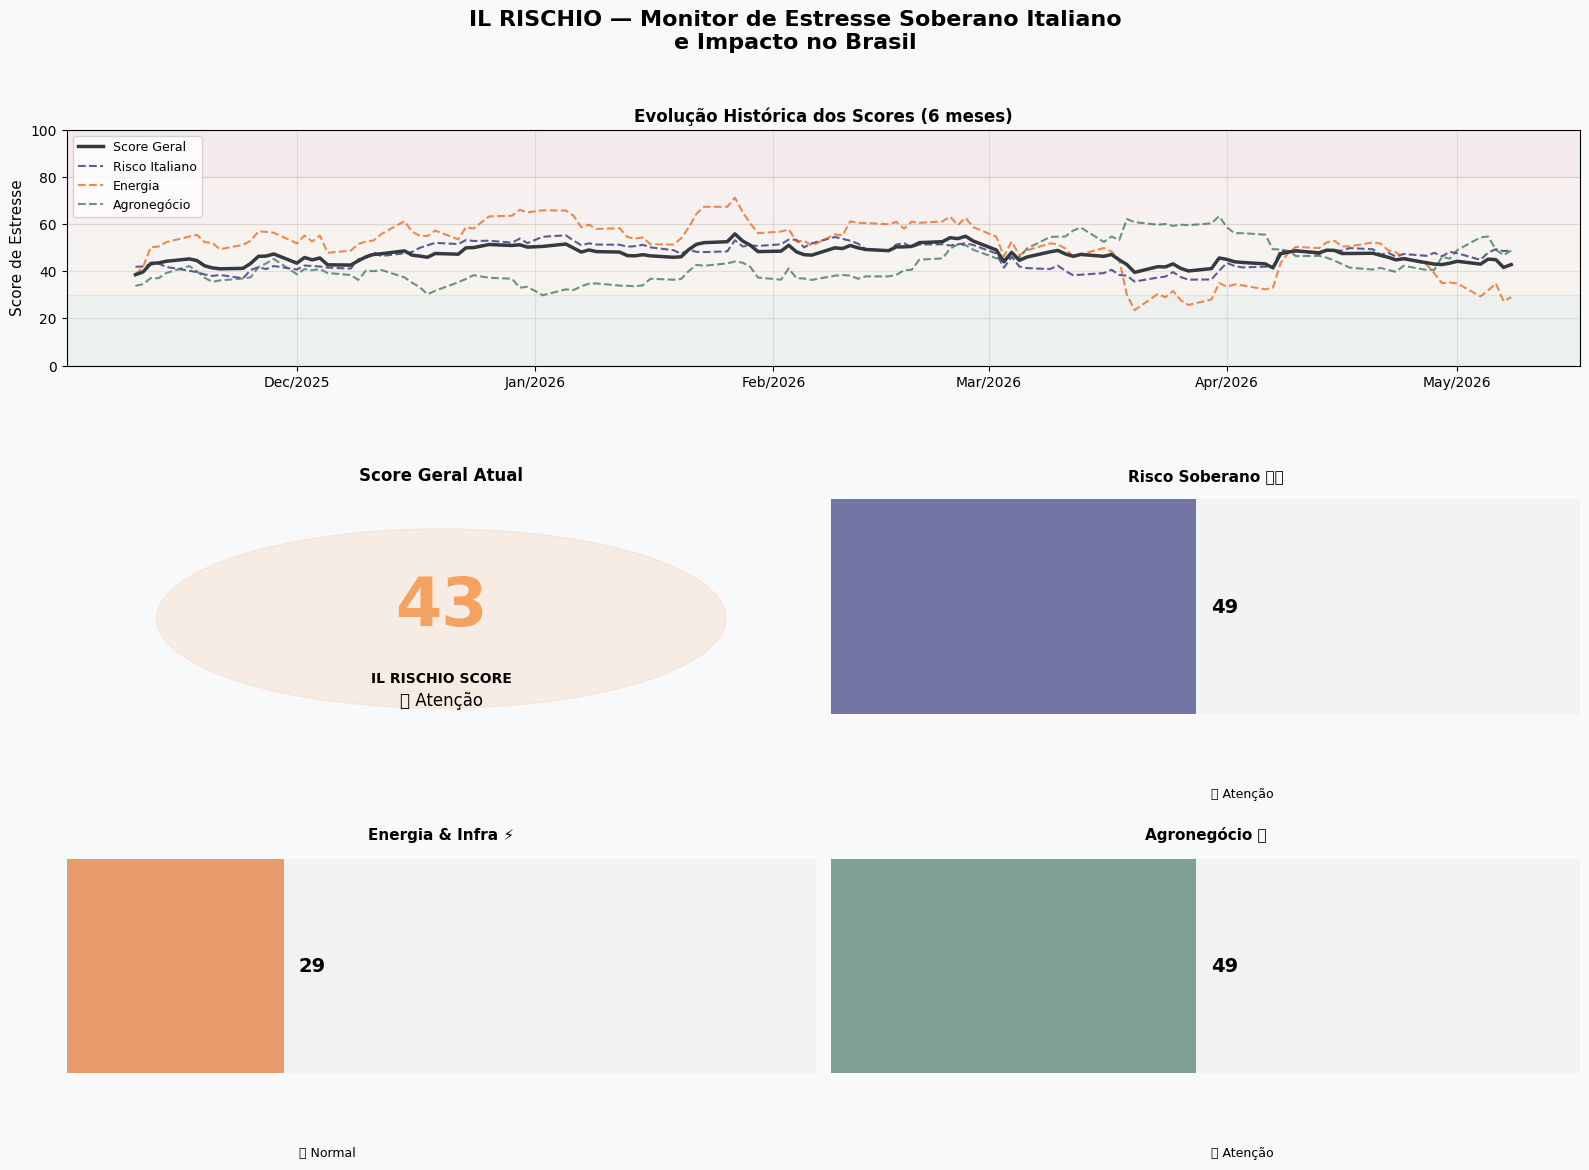

✓ Dashboard salvo: il_rischio_dashboard.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import FancyBboxPatch

print("=" * 50)
print("MÓDULO 4 — DASHBOARD")
print("=" * 50)

# Paleta de cores
CORES = {
    "italia":  "#1a1a6e",
    "energia": "#e85d04",
    "agro":    "#2d6a4f",
    "geral":   "#343a40",
    "fundo":   "#f8f9fa",
}

def cor_score(score):
    if score < 30:   return "#2d6a4f"
    elif score < 60: return "#f4a261"
    elif score < 80: return "#e76f51"
    else:            return "#c1121f"

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor(CORES["fundo"])
fig.suptitle("IL RISCHIO — Monitor de Estresse Soberano Italiano\ne Impacto no Brasil",
             fontsize=16, fontweight="bold", y=0.98)

# ── Linha do tempo dos scores ─────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 2, (1, 2))
ax1.set_facecolor(CORES["fundo"])

idx_comum = score_geral.dropna().index

ax1.plot(idx_comum, score_geral.reindex(idx_comum),
         color=CORES["geral"], linewidth=2.5, label="Score Geral", zorder=5)
ax1.plot(idx_comum, score_italia.reindex(idx_comum),
         color=CORES["italia"], linewidth=1.5, alpha=0.7, label="Risco Italiano", linestyle="--")
ax1.plot(idx_comum, score_energia.reindex(idx_comum),
         color=CORES["energia"], linewidth=1.5, alpha=0.7, label="Energia", linestyle="--")
ax1.plot(idx_comum, score_agro.reindex(idx_comum),
         color=CORES["agro"], linewidth=1.5, alpha=0.7, label="Agronegócio", linestyle="--")

# Faixas de alerta
ax1.axhspan(0,  30, alpha=0.06, color="#2d6a4f")
ax1.axhspan(30, 60, alpha=0.06, color="#f4a261")
ax1.axhspan(60, 80, alpha=0.06, color="#e76f51")
ax1.axhspan(80, 100, alpha=0.06, color="#c1121f")

ax1.set_ylim(0, 100)
ax1.set_ylabel("Score de Estresse", fontsize=11)
ax1.set_title("Evolução Histórica dos Scores (6 meses)", fontsize=12, fontweight="bold")
ax1.legend(loc="upper left", fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
ax1.grid(True, alpha=0.3)

# ── Gauge atual — Score Geral ─────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 2, 3)
ax2.set_facecolor(CORES["fundo"])
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.axis("off")

cor = cor_score(ultimo_geral)
circulo = plt.Circle((0.5, 0.45), 0.38, color=cor, alpha=0.15)
ax2.add_patch(circulo)
ax2.text(0.5, 0.50, f"{ultimo_geral:.0f}", ha="center", va="center",
         fontsize=48, fontweight="bold", color=cor)
ax2.text(0.5, 0.18, "IL RISCHIO SCORE", ha="center", fontsize=10, fontweight="bold")
ax2.text(0.5, 0.08, classificar_alerta(ultimo_geral), ha="center", fontsize=12)
ax2.set_title("Score Geral Atual", fontsize=12, fontweight="bold")

# ── Scores setoriais ──────────────────────────────────────────────────────────
for ax, score, titulo, cor in [
    (fig.add_subplot(3, 2, 4), ultimo_italia,  "Risco Soberano 🇮🇹", CORES["italia"]),
    (fig.add_subplot(3, 2, 5), ultimo_energia, "Energia & Infra ⚡",  CORES["energia"]),
    (fig.add_subplot(3, 2, 6), ultimo_agro,    "Agronegócio 🌾",      CORES["agro"]),
]:
    ax.set_facecolor(CORES["fundo"])
    ax.barh([""], [score], color=cor, alpha=0.8, height=0.4)
    ax.barh([""], [100],   color="#dee2e6", alpha=0.3, height=0.4)
    ax.set_xlim(0, 100)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.text(score + 2, 0, f"{score:.0f}", va="center", fontsize=14, fontweight="bold")
    ax.text(score + 2, -0.35, classificar_alerta(score), va="center", fontsize=9)
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("il_rischio_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=CORES["fundo"])
plt.show()
print("✓ Dashboard salvo: il_rischio_dashboard.png")

In [23]:
!pip install reportlab -q
print("✓ ReportLab instalado")

✓ ReportLab instalado


In [40]:
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT, TA_JUSTIFY
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import io

print("=" * 50)
print("MÓDULO 4A — RELATÓRIO PDF")
print("=" * 50)

# ── Paleta de cores ───────────────────────────────────────────────────────────
AZUL_ESCURO  = colors.HexColor("#1a1a6e")
LARANJA      = colors.HexColor("#e85d04")
VERDE        = colors.HexColor("#2d6a4f")
CINZA_ESCURO = colors.HexColor("#343a40")
CINZA_CLARO  = colors.HexColor("#f8f9fa")
AMARELO      = colors.HexColor("#f4a261")
VERMELHO     = colors.HexColor("#c1121f")
BRANCO       = colors.white

def cor_score_rl(score):
    """Retorna cor ReportLab baseada no score."""
    if score < 30:   return colors.HexColor("#2d6a4f")
    elif score < 60: return colors.HexColor("#f4a261")
    elif score < 80: return colors.HexColor("#e76f51")
    else:            return colors.HexColor("#c1121f")

def label_score(score):
    if score < 30:   return "NORMAL"
    elif score < 60: return "ATENÇÃO"
    elif score < 80: return "ALERTA"
    else:            return "CRÍTICO"

def gerar_interpretacao(score_geral, score_italia, score_energia, score_agro):
    """Gera parágrafo automático de interpretação baseado nos scores."""

    data_ref = FIM.strftime("%d/%m/%Y")

    # Contexto geral
    if score_geral < 30:
        contexto = f"Na semana encerrada em {data_ref}, o Il Rischio Score Geral registrou {score_geral:.0f} pontos, indicando um ambiente de <b>baixo estresse</b> nos canais de transmissão entre o risco soberano italiano e os setores brasileiros monitorados."
    elif score_geral < 60:
        contexto = f"Na semana encerrada em {data_ref}, o Il Rischio Score Geral registrou {score_geral:.0f} pontos, sinalizando um nível <b>moderado de atenção</b> nos canais de transmissão entre o risco soberano italiano e os setores brasileiros monitorados."
    elif score_geral < 80:
        contexto = f"Na semana encerrada em {data_ref}, o Il Rischio Score Geral registrou {score_geral:.0f} pontos, indicando <b>estresse relevante</b> nos canais de transmissão entre o risco soberano italiano e os setores brasileiros monitorados. Recomenda-se atenção redobrada às carteiras expostas."
    else:
        contexto = f"Na semana encerrada em {data_ref}, o Il Rischio Score Geral registrou {score_geral:.0f} pontos, sinalizando nível <b>crítico de estresse</b>. A probabilidade de transmissão do risco europeu para setores corporativos brasileiros é elevada."

    # Análise italiana
    if score_italia >= 60:
        italia_txt = f"O risco soberano italiano ({score_italia:.0f} pts) encontra-se em zona de alerta, com o spread BTP-Bund e o sentimento do mercado europeu pressionados. Historicamente, episódios neste patamar precedem aperto nas condições de crédito para mercados emergentes em 4 a 8 semanas."
    else:
        italia_txt = f"O risco soberano italiano ({score_italia:.0f} pts) permanece em nível controlado, sem sinais imediatos de contágio para mercados emergentes via canal de liquidez europeu."

    # Análise de energia
    if score_energia >= 60:
        energia_txt = f"O setor de Energia & Infraestrutura ({score_energia:.0f} pts) apresenta sinais de estresse, com custo de funding elevado e pressão sobre empresas do setor elétrico brasileiro. Operações de project finance e emissões de debêntures incentivadas podem enfrentar condições menos favoráveis."
    else:
        energia_txt = f"O setor de Energia & Infraestrutura ({score_energia:.0f} pts) opera em ambiente relativamente estável, com custo de funding controlado e sem pressão aguda sobre o pipeline de emissões do setor."

    # Análise de agro
    if score_agro >= 60:
        agro_txt = f"O Agronegócio ({score_agro:.0f} pts) apresenta sinais preocupantes, com pressão simultânea sobre preços de commodities e condições de crédito. O monitoramento de CRAs e operações de crédito estruturado para o setor é recomendado."
    else:
        agro_txt = f"O Agronegócio ({score_agro:.0f} pts) não apresenta sinais agudos de estresse no horizonte analisado, embora o nível de inadimplência setorial mereça acompanhamento contínuo dado o ciclo de juros elevados."

    return contexto, italia_txt, energia_txt, agro_txt

# ── Gráfico para o PDF ────────────────────────────────────────────────────────
def gerar_grafico_pdf():
    """Gera o gráfico de evolução dos scores e retorna como imagem em bytes."""
    fig, ax = plt.subplots(figsize=(16, 5))
    fig.patch.set_facecolor("#f8f9fa")
    ax.set_facecolor("#f8f9fa")

    idx = score_geral.dropna().index

    ax.plot(idx, score_geral.reindex(idx),
            color="#343a40", linewidth=2.5, label="Score Geral", zorder=5)
    ax.plot(idx, score_italia.reindex(idx),
            color="#1a1a6e", linewidth=1.5, alpha=0.8,
            label="Risco Italiano", linestyle="--")
    ax.plot(idx, score_energia.reindex(idx),
            color="#e85d04", linewidth=1.5, alpha=0.8,
            label="Energia & Infra", linestyle="--")
    ax.plot(idx, score_agro.reindex(idx),
            color="#2d6a4f", linewidth=1.5, alpha=0.8,
            label="Agronegócio", linestyle="--")

    ax.axhspan(0,  30, alpha=0.06, color="#2d6a4f", label="_nolegend_")
    ax.axhspan(30, 60, alpha=0.06, color="#f4a261", label="_nolegend_")
    ax.axhspan(60, 80, alpha=0.06, color="#e76f51", label="_nolegend_")
    ax.axhspan(80, 100, alpha=0.06, color="#c1121f", label="_nolegend_")

    # Linhas de referência
    for y, label in [(30, "Normal/Atenção"), (60, "Atenção/Alerta"), (80, "Alerta/Crítico")]:
        ax.axhline(y=y, color="gray", linewidth=0.5, linestyle=":", alpha=0.5)
        ax.text(idx[-1], y + 1, label, fontsize=7, color="gray", ha="right")

    ax.set_ylim(0, 100)
    ax.set_ylabel("Score de Estresse", fontsize=11)
    ax.set_title("Evolução Histórica dos Scores — Últimos 6 Meses", fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
    ax.grid(True, alpha=0.3)

    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="#f8f9fa")
    plt.close()
    buf.seek(0)
    return buf

# ── Construção do PDF ─────────────────────────────────────────────────────────
def gerar_pdf():
    nome_arquivo = f"il_rischio_{FIM.strftime('%Y%m%d')}.pdf"
    doc = SimpleDocTemplate(
        nome_arquivo,
        pagesize=A4,
        rightMargin=2*cm,
        leftMargin=2*cm,
        topMargin=2*cm,
        bottomMargin=2*cm,
    )

    styles = getSampleStyleSheet()
    elementos = []

    # ── Estilos customizados ──────────────────────────────────────────────────
    estilo_titulo = ParagraphStyle(
        "titulo",
        parent=styles["Normal"],
        fontSize=22,
        fontName="Helvetica-Bold",
        textColor=AZUL_ESCURO,
        alignment=TA_CENTER,
        spaceAfter=4,
    )
    estilo_subtitulo = ParagraphStyle(
        "subtitulo",
        parent=styles["Normal"],
        fontSize=11,
        fontName="Helvetica",
        textColor=CINZA_ESCURO,
        alignment=TA_CENTER,
        spaceAfter=2,
    )
    estilo_secao = ParagraphStyle(
        "secao",
        parent=styles["Normal"],
        fontSize=13,
        fontName="Helvetica-Bold",
        textColor=AZUL_ESCURO,
        spaceBefore=14,
        spaceAfter=6,
        borderPad=4,
    )
    estilo_corpo = ParagraphStyle(
        "corpo",
        parent=styles["Normal"],
        fontSize=10,
        fontName="Helvetica",
        textColor=CINZA_ESCURO,
        alignment=TA_JUSTIFY,
        spaceAfter=6,
        leading=15,
    )
    estilo_nota = ParagraphStyle(
        "nota",
        parent=styles["Normal"],
        fontSize=8,
        fontName="Helvetica-Oblique",
        textColor=colors.HexColor("#888888"),
        alignment=TA_CENTER,
        spaceAfter=4,
    )

    # ── Cabeçalho ─────────────────────────────────────────────────────────────
    elementos.append(Spacer(1, 0.3*cm))
    elementos.append(Paragraph("IL RISCHIO", estilo_titulo))
    elementos.append(Spacer(1, 0.3*cm))
    elementos.append(Paragraph(
    "Monitor de Estresse Soberano Italiano e Impacto no Brasil",
    estilo_subtitulo,
    ))
    elementos.append(Paragraph(
        f"Relatório Semanal — {data_pt(FIM)}  |  Desenvolvido por Felipe S. S. Alves  |  Bocconi Students Emerging Markets Club",
        estilo_nota,
    ))
    elementos.append(HRFlowable(width="100%", thickness=1.5,
                                color=AZUL_ESCURO, spaceAfter=12))

    # ── Tabela de scores ──────────────────────────────────────────────────────
    elementos.append(Paragraph("Scores de Estresse Atuais", estilo_secao))

    scores_data = [
        ["Indicador", "Score", "Status"],
        ["🎯  Il Rischio Score Geral", f"{ultimo_geral:.0f} / 100", label_score(ultimo_geral)],
        ["🇮🇹  Risco Soberano Italiano", f"{ultimo_italia:.0f} / 100", label_score(ultimo_italia)],
        ["⚡  Energia & Infraestrutura", f"{ultimo_energia:.0f} / 100", label_score(ultimo_energia)],
        ["🌾  Agronegócio",              f"{ultimo_agro:.0f} / 100",   label_score(ultimo_agro)],
    ]

    tabela = Table(scores_data, colWidths=[9*cm, 4*cm, 4*cm])
    tabela.setStyle(TableStyle([
        # Cabeçalho
        ("BACKGROUND",   (0, 0), (-1, 0),  AZUL_ESCURO),
        ("TEXTCOLOR",    (0, 0), (-1, 0),  BRANCO),
        ("FONTNAME",     (0, 0), (-1, 0),  "Helvetica-Bold"),
        ("FONTSIZE",     (0, 0), (-1, 0),  10),
        ("ALIGN",        (0, 0), (-1, 0),  "CENTER"),
        ("BOTTOMPADDING",(0, 0), (-1, 0),  10),
        ("TOPPADDING",   (0, 0), (-1, 0),  10),
        # Linha do score geral
        ("BACKGROUND",   (0, 1), (-1, 1),  colors.HexColor("#e8e8f0")),
        ("FONTNAME",     (0, 1), (-1, 1),  "Helvetica-Bold"),
        ("FONTSIZE",     (0, 1), (-1, 1),  11),
        # Linhas normais
        ("FONTNAME",     (0, 2), (-1, -1), "Helvetica"),
        ("FONTSIZE",     (0, 2), (-1, -1), 10),
        ("ROWBACKGROUNDS",(0, 2), (-1, -1), [BRANCO, CINZA_CLARO]),
        # Alinhamento
        ("ALIGN",        (1, 1), (-1, -1), "CENTER"),
        ("VALIGN",       (0, 0), (-1, -1), "MIDDLE"),
        ("TOPPADDING",   (0, 1), (-1, -1), 8),
        ("BOTTOMPADDING",(0, 1), (-1, -1), 8),
        ("LEFTPADDING",  (0, 0), (-1, -1), 10),
        # Bordas
        ("GRID",         (0, 0), (-1, -1), 0.5, colors.HexColor("#dee2e6")),
        ("BOX",          (0, 0), (-1, -1), 1.0, AZUL_ESCURO),
        # Cores dos status
        ("TEXTCOLOR",    (2, 2), (2, 2),
         cor_score_rl(ultimo_italia)),
        ("TEXTCOLOR",    (2, 3), (2, 3),
         cor_score_rl(ultimo_energia)),
        ("TEXTCOLOR",    (2, 4), (2, 4),
         cor_score_rl(ultimo_agro)),
        ("FONTNAME",     (2, 1), (2, -1), "Helvetica-Bold"),
    ]))
    elementos.append(tabela)

    # ── Gráfico ───────────────────────────────────────────────────────────────
    elementos.append(Paragraph("Evolução Histórica dos Scores", estilo_secao))

    from reportlab.platypus import Image as RLImage
    buf_grafico = gerar_grafico_pdf()
    img = RLImage(buf_grafico, width=17*cm, height=6*cm)
    elementos.append(img)

    # ── Interpretação ─────────────────────────────────────────────────────────
    elementos.append(Paragraph("Interpretação Automática", estilo_secao))

    contexto, italia_txt, energia_txt, agro_txt = gerar_interpretacao(
        ultimo_geral, ultimo_italia, ultimo_energia, ultimo_agro
    )

    for texto in [contexto, italia_txt, energia_txt, agro_txt]:
        elementos.append(Paragraph(texto, estilo_corpo))

    # ── Tabela de indicadores detalhados ──────────────────────────────────────
    elementos.append(Paragraph("Indicadores Detalhados", estilo_secao))

    def variacao(serie):
        """Calcula variação semanal do indicador."""
        s = serie.dropna()
        if len(s) < 6:
            return "—"
        var = ((s.iloc[-1] / s.iloc[-6]) - 1) * 100
        sinal = "▲" if var > 0 else "▼"
        return f"{sinal} {abs(var):.1f}%"

    indicadores_det = [
        ["Indicador", "Último Valor", "Var. Semanal", "Setor"],
        ["BTP-Bund Spread",
         f"{btp_bund.dropna().iloc[-1]:.2f}%" if not btp_bund.empty else "—",
         variacao_inteligente(btp_bund, "btp_bund"),
         "Itália"],
        ["EUR/BRL",
         f"R$ {eur_brl.dropna().iloc[-1]:.4f}",
         variacao_inteligente(eur_brl),
         "Itália"],
        ["EWI (MSCI Italy ETF)",
         f"US$ {ewi.dropna().iloc[-1]:.2f}",
         variacao_inteligente(ewi),
         "Itália"],
        ["FTSE MIB",
         f"{ftsemib.dropna().iloc[-1]:,.0f}",
         variacao_inteligente(ftsemib, "ftsemib"),
         "Itália"],
        ["Capital Flow (taxa overnight IT)",
         f"{capital_flow.dropna().iloc[-1]:.2f}%" if not capital_flow.empty else "—",
         variacao_inteligente(capital_flow, "capital_flow"),
         "Itália"],
        ["Selic (% a.a.)",
         f"{selic_anual.dropna().iloc[-1]:.2f}%",
         variacao_inteligente(selic_anual, "selic"),
         "Energia"],
        ["CPFE3",
         f"R$ {cpfe3.dropna().iloc[-1]:.2f}",
         variacao_inteligente(cpfe3),
         "Energia"],
        ["TAEE11",
         f"R$ {taee11.dropna().iloc[-1]:.2f}",
         variacao_inteligente(taee11),
         "Energia"],
        ["Soja (CBOT)",
         f"US$ {soja.dropna().iloc[-1]:.2f}",
         variacao_inteligente(soja),
         "Agro"],
        ["Açúcar (ICE)",
         f"US$ {acucar.dropna().iloc[-1]:.2f}",
         variacao_inteligente(acucar),
         "Agro"],
        ["AGRO3",
         f"R$ {agro3.dropna().iloc[-1]:.2f}",
         variacao_inteligente(agro3),
         "Agro"],
        ["SLCE3",
         f"R$ {slce3.dropna().iloc[-1]:.2f}",
         variacao_inteligente(slce3),
         "Agro"],
    ]

    tabela_det = Table(indicadores_det, colWidths=[6*cm, 4*cm, 3.5*cm, 3.5*cm])
    tabela_det.setStyle(TableStyle([
        ("BACKGROUND",    (0, 0), (-1, 0),  AZUL_ESCURO),
        ("TEXTCOLOR",     (0, 0), (-1, 0),  BRANCO),
        ("FONTNAME",      (0, 0), (-1, 0),  "Helvetica-Bold"),
        ("FONTSIZE",      (0, 0), (-1, -1), 9),
        ("ALIGN",         (1, 0), (-1, -1), "CENTER"),
        ("VALIGN",        (0, 0), (-1, -1), "MIDDLE"),
        ("TOPPADDING",    (0, 0), (-1, -1), 6),
        ("BOTTOMPADDING", (0, 0), (-1, -1), 6),
        ("LEFTPADDING",   (0, 0), (-1, -1), 8),
        ("ROWBACKGROUNDS",(0, 1), (-1, -1), [BRANCO, CINZA_CLARO]),
        ("GRID",          (0, 0), (-1, -1), 0.5, colors.HexColor("#dee2e6")),
        ("BOX",           (0, 0), (-1, -1), 1.0, AZUL_ESCURO),
    ]))
    elementos.append(tabela_det)

    # ── Rodapé ────────────────────────────────────────────────────────────────
    elementos.append(Spacer(1, 0.5*cm))
    elementos.append(HRFlowable(width="100%", thickness=0.5,
                                color=colors.HexColor("#dee2e6"), spaceAfter=6))
    elementos.append(Paragraph(
        "Il Rischio é um projeto acadêmico independente desenvolvido no contexto do Bocconi Students Emerging Markets Club. "
        "As informações contidas neste relatório têm caráter exclusivamente analítico e não constituem recomendação de investimento. "
        f"Gerado automaticamente em {data_pt(FIM)} às {FIM.strftime('%H:%M')}.",
        estilo_nota,
    ))

    # ── Gerar PDF ─────────────────────────────────────────────────────────────
    doc.build(elementos)
    print(f"✓ PDF gerado: {nome_arquivo}")
    return nome_arquivo

# Rodar
nome_pdf = gerar_pdf()

MÓDULO 4A — RELATÓRIO PDF
✓ PDF gerado: il_rischio_20260509.pdf


In [25]:
from google.colab import files
files.download(f"il_rischio_{FIM.strftime('%Y%m%d')}.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import locale

# Corrige a data para português
MESES_PT = {
    "January": "janeiro", "February": "fevereiro", "March": "março",
    "April": "abril", "May": "maio", "June": "junho",
    "July": "julho", "August": "agosto", "September": "setembro",
    "October": "outubro", "November": "novembro", "December": "dezembro"
}

def data_pt(dt):
    """Formata data em português."""
    mes_en = dt.strftime("%B")
    return dt.strftime(f"%d de {MESES_PT[mes_en]} de %Y")

# Corrige a Selic — multiplica por 252 para anualizar a taxa diária
selic_anual = (selic * 252).rename("selic")
selic_anual = selic_anual.clip(upper=20)  # limita outliers

# Substitui a série nos indicadores de energia
indicadores_energia["selic"] = selic_anual

# Reprocessa o setor de energia com a Selic corrigida
df_energia_raw, df_energia_norm = processar_setor(indicadores_energia)

# Recalcula scores
score_energia = calcular_score(df_energia_norm, PESOS_ENERGIA)
score_geral   = (0.40 * score_italia + 0.30 * score_energia + 0.30 * score_agro).round(1)

ultimo_energia = score_energia.dropna().iloc[-1]
ultimo_geral   = score_geral.dropna().iloc[-1]

print(f"✓ Selic anualizada: {selic_anual.dropna().iloc[-1]:.2f}% a.a.")
print(f"✓ Score Energia atualizado: {ultimo_energia:.1f}")
print(f"✓ Score Geral atualizado:   {ultimo_geral:.1f}")

✓ Selic anualizada: 13.46% a.a.
✓ Score Energia atualizado: 29.0
✓ Score Geral atualizado:   42.8


In [28]:
nome_pdf = gerar_pdf()
files.download(f"il_rischio_{FIM.strftime('%Y%m%d')}.pdf")

✓ PDF gerado: il_rischio_20260509.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
nome_pdf = gerar_pdf()
files.download(f"il_rischio_{FIM.strftime('%Y%m%d')}.pdf")

✓ PDF gerado: il_rischio_20260509.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
nome_pdf = gerar_pdf()
files.download(f"il_rischio_{FIM.strftime('%Y%m%d')}.pdf")

✓ PDF gerado: il_rischio_20260509.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
def variacao_inteligente(serie, nome=""):
    """
    Calcula variação semanal ou mensal dependendo da frequência da série.
    Evita mostrar 0.0% quando os valores são idênticos por forward fill.
    """
    s = serie.dropna()

    if len(s) < 2:
        return "—"

    # Detecta se é série mensal (poucos pontos)
    if len(s) <= 6:
        # Usa variação entre primeiro e último ponto disponível
        var = ((s.iloc[-1] / s.iloc[0]) - 1) * 100
        if abs(var) < 0.001:
            return "—"
        sinal = "▲" if var > 0 else "▼"
        return f"{sinal} {abs(var):.1f}% (mensal)"

    # Série diária — verifica se há variação real nos últimos 6 dias
    janela = s.iloc[-6:]
    if janela.nunique() == 1:
        # Todos os valores são iguais — forward fill sem atualização
        # Busca último valor diferente do atual
        atual = s.iloc[-1]
        anteriores = s[s != atual]
        if anteriores.empty:
            return "—"
        var = ((atual / anteriores.iloc[-1]) - 1) * 100
        if abs(var) < 0.001:
            return "—"
        sinal = "▲" if var > 0 else "▼"
        return f"{sinal} {abs(var):.1f}%"

    # Variação semanal normal
    var = ((s.iloc[-1] / s.iloc[-6]) - 1) * 100
    if abs(var) < 0.001:
        return "—"
    sinal = "▲" if var > 0 else "▼"
    return f"{sinal} {abs(var):.1f}%"

print("✓ Função de variação atualizada")

✓ Função de variação atualizada


In [36]:
nome_pdf = gerar_pdf()
files.download(f"il_rischio_{FIM.strftime('%Y%m%d')}.pdf")

✓ PDF gerado: il_rischio_20260509.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
def variacao_inteligente(serie, nome=""):
    s = serie.dropna()

    if len(s) < 2:
        return "—"

    # Série mensal
    if len(s) <= 6:
        var = ((s.iloc[-1] / s.iloc[0]) - 1) * 100
        if abs(var) < 0.01:
            return "—"
        sinal = "▲" if var > 0 else "▼"
        return f"{sinal} {abs(var):.1f}% (mensal)"

    # Série diária — verifica variação real
    atual = s.iloc[-1]
    anteriores = s[s != atual]
    if anteriores.empty:
        return "—"

    var = ((atual / anteriores.iloc[-1]) - 1) * 100
    if abs(var) < 0.05:  # ignora variações menores que 0.05%
        return "—"
    sinal = "▲" if var > 0 else "▼"
    return f"{sinal} {abs(var):.1f}%"

print("✓ Função corrigida")

✓ Função corrigida


In [38]:
nome_pdf = gerar_pdf()
files.download(f"il_rischio_{FIM.strftime('%Y%m%d')}.pdf")

✓ PDF gerado: il_rischio_20260509.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
def variacao_inteligente(serie, nome=""):
    s = serie.dropna()

    if len(s) < 2:
        return "—"

    # Série mensal (poucos pontos)
    if len(s) <= 6:
        var = ((s.iloc[-1] / s.iloc[0]) - 1) * 100
        if abs(var) < 0.01:
            return "—"
        sinal = "▲" if var > 0 else "▼"
        return f"{sinal} {abs(var):.1f}% (mensal)"

    # Selic — taxa de política monetária, não mostra variação semanal
    if nome == "selic":
        return "—"

    # Série diária — compara último valor com 5 dias úteis atrás
    ultimo = s.iloc[-1]
    anterior = s.iloc[-6] if len(s) >= 6 else s.iloc[0]

    if anterior == 0:
        return "—"

    var = ((ultimo / anterior) - 1) * 100

    if abs(var) < 0.05:
        return "—"

    sinal = "▲" if var > 0 else "▼"
    return f"{sinal} {abs(var):.1f}%"

print("✓ Função corrigida")

✓ Função corrigida


In [41]:
nome_pdf = gerar_pdf()
files.download(f"il_rischio_{FIM.strftime('%Y%m%d')}.pdf")

✓ PDF gerado: il_rischio_20260509.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
def variacao_inteligente(serie, nome=""):
    s = serie.dropna()

    if len(s) < 2:
        return "—"

    # Série mensal
    if len(s) <= 6:
        var = ((s.iloc[-1] / s.iloc[0]) - 1) * 100
        if abs(var) < 0.01:
            return "—"
        sinal = "▲" if var > 0 else "▼"
        return f"{sinal} {abs(var):.1f}% (mensal)"

    # Selic — taxa de política monetária
    if nome == "selic":
        return "—"

    # Série diária
    ultimo = s.iloc[-1]
    anterior = s.iloc[-6] if len(s) >= 6 else s.iloc[0]

    if anterior == 0:
        return "—"

    var = ((ultimo / anterior) - 1) * 100

    if abs(var) < 0.01:  # threshold reduzido de 0.05% para 0.01%
        return "—"

    sinal = "▲" if var > 0 else "▼"
    return f"{sinal} {abs(var):.1f}%"

print("✓ Função corrigida")

✓ Função corrigida


In [43]:
nome_pdf = gerar_pdf()
files.download(f"il_rischio_{FIM.strftime('%Y%m%d')}.pdf")

✓ PDF gerado: il_rischio_20260509.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
def variacao_inteligente(serie, nome=""):
    s = serie.dropna()

    if len(s) < 2:
        return "—"

    # Série mensal
    if len(s) <= 6:
        var = ((s.iloc[-1] / s.iloc[0]) - 1) * 100
        if abs(var) < 0.01:
            return "—"
        sinal = "▲" if var > 0 else "▼"
        return f"{sinal} {abs(var):.1f}% (mensal)"

    # Selic
    if nome == "selic":
        return "—"

    # Série diária
    ultimo = s.iloc[-1]
    anterior = s.iloc[-6] if len(s) >= 6 else s.iloc[0]

    if anterior == 0:
        return "—"

    var = ((ultimo / anterior) - 1) * 100

    # Mostra "—" se variação for zero ou virtualmente zero
    if round(var, 2) == 0.0:
        return "—"

    sinal = "▲" if var > 0 else "▼"
    return f"{sinal} {abs(var):.1f}%"

print("✓ Função corrigida")

✓ Função corrigida


In [45]:
nome_pdf = gerar_pdf()
files.download(f"il_rischio_{FIM.strftime('%Y%m%d')}.pdf")

✓ PDF gerado: il_rischio_20260509.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
print("Últimos 10 valores do CPFE3:")
print(cpfe3.dropna().tail(10).to_string())

Últimos 10 valores do CPFE3:
Date
2026-04-24    49.388653
2026-04-27    48.906994
2026-04-28    47.749157
2026-04-29    46.878464
2026-04-30    48.930000
2026-05-04    48.099998
2026-05-05    49.410000
2026-05-06    49.740002
2026-05-07    48.230000
2026-05-08    48.939999


In [47]:
def variacao_inteligente(serie, nome=""):
    s = serie.dropna()

    if len(s) < 2:
        return "—"

    # Série mensal
    if len(s) <= 6:
        var = ((s.iloc[-1] / s.iloc[0]) - 1) * 100
        if abs(var) < 0.01:
            return "—"
        sinal = "▲" if var > 0 else "▼"
        return f"{sinal} {abs(var):.1f}% (mensal)"

    # Selic
    if nome == "selic":
        return "—"

    # Série diária
    ultimo  = s.iloc[-1]
    anterior = s.iloc[-6] if len(s) >= 6 else s.iloc[0]

    if anterior == 0:
        return "—"

    var = ((ultimo / anterior) - 1) * 100

    if abs(var) == 0:
        return "—"

    sinal = "▲" if var > 0 else "▼"

    # Usa 2 casas decimais para variações muito pequenas
    if abs(var) < 0.1:
        return f"{sinal} {abs(var):.2f}%"

    return f"{sinal} {abs(var):.1f}%"

print("✓ Função corrigida")
print(f"\nTeste CPFE3: {variacao_inteligente(cpfe3)}")

✓ Função corrigida

Teste CPFE3: ▲ 0.02%


In [48]:
nome_pdf = gerar_pdf()
files.download(f"il_rischio_{FIM.strftime('%Y%m%d')}.pdf")

✓ PDF gerado: il_rischio_20260509.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>